# One update, then a semantic cliff

**Workshop storyboard: what a transplanted value controls in a fully written
reasoning trace.**

This notebook is the short paper story. Notebook 15 remains the complete
experiment record. Every number below comes from a committed artifact under
`results/dag_patching/`; the notebook runs no model.

## Paper claim

We transplant the residual state of one arithmetic line from a counterfactual
donor trace into the same token positions of a clean trace. The generated task
names three different outcomes before the intervention: the clean answer, the
answer implied by applying the recipient's remaining arithmetic to the donor
value, and the raw digit written by the donor.

In `DeepSeek-R1-Distill-Qwen-1.5B`, one-update sites land on the implied digit in
555/603 eligible cases. Sites with two or more written operations remaining do
so in 0/432 cases. A same-trace control gives the sharpest comparison: patching
the last intermediate succeeds in 144/144 items while patching its ancestor
succeeds in 0/144. Total variation still changes at multi-step sites, so the
result is a semantic cliff over a graded distributional effect.

The claim is limited to one checkpoint and one fully written synthetic format.
The design rules out token distance and clean confidence as sole explanations.
It does not isolate written-step count from operation, binding, local context,
or patch-site role.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from matplotlib.patches import Rectangle
from scipy.stats import fisher_exact

sys.path.insert(0, str(Path.cwd()))
import _viz_utils as vu

ROOT = vu.repo_root()
DAG = ROOT / "results/dag_patching"
LAYER = 13  # the joint layer every count below is read at; see section 3


def arm(relpath):
    """One patched run, or any other record under results/dag_patching/."""
    with (DAG / relpath).open(encoding="utf-8") as handle:
        return json.load(handle)


POOLED = arm("POOLED.json")
STAGE_B = arm("e2_stage_b/ANALYSIS.json")["analysis"]
SELECTION = arm("e2_screening/SELECTION.json")
PRIMARY = STAGE_B["primary"]
E3 = arm("e3_ladder/ANALYSIS.json")  # the campaign at 48 items a seed, §9

# ---------------------------------------------------------------------------
# Presentation only. Nothing below this line touches a number.
# ---------------------------------------------------------------------------
INK, MUTED, PAPER = "#1a1a1a", "#5b5b5b", "#ffffff"
SANS = "-apple-system,BlinkMacSystemFont,Segoe UI,Helvetica,Arial,sans-serif"
COLOR = {
    "ancestor": "#c0392b", "non-ancestor": "#7f8c8d", "surface null": "#b8bfc4",
    "worst null": "#34495e", "clean": "#9ec4e8", "patched": "#c0392b",
    1: "#c0392b", 2: "#2c6fbb", 3: "#4f9153",
}
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9a9a9a", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

_RULES = [
    {"selector": "", "props": [("border-collapse", "collapse"), ("font-size", "12px")]},
    {"selector": "th", "props": [("text-align", "right"), ("font-weight", "600"),
                                 ("padding", "5px 13px"), ("border", "none"),
                                 ("border-bottom", "1px solid #9a9a9a")]},
    {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 13px"),
                                 ("border", "none")]},
    {"selector": "thead tr", "props": [("border-top", "1.4px solid #222")]},
    {"selector": "tbody tr:last-child td",
     "props": [("border-bottom", "1.4px solid #222")]},
]


def table(frame, title, note=None, highlight=None, **formats):
    """A frame as a ruled table with a title and a reading note.

    `highlight` is a boolean sequence over rows: the row a claim rests on gets
    tinted instead of getting its own sentence.
    """
    text_cols = [i for i, name in enumerate(frame.columns)
                 if not pd.api.types.is_numeric_dtype(frame[name])]
    styler = (
        frame.style.hide(axis="index")
        .format(formats or None)
        .set_table_styles(_RULES + [
            {"selector": f"{tag}.col{i}", "props": [("text-align", "left")]}
            for i in text_cols for tag in ("th", "td")
        ])
    )
    if highlight is not None:
        styler = styler.apply(
            lambda _col, mask=list(highlight):
                ["background-color: #fbf0da" if flag else "" for flag in mask],
            axis=0,
        )
    head = f"<div style='font:600 13px/1.4 {SANS};margin:0 0 8px'>{title}</div>"
    tail = (f"<div style='font:400 11.5px/1.55 {SANS};color:{MUTED};max-width:760px;"
            f"margin:9px 0 0'>{note}</div>") if note else ""
    display(HTML(f"<div style='background:{PAPER};color:{INK};padding:12px 14px 14px;"
                 f"display:inline-block;font-family:{SANS}'>"
                 f"{head}{styler.to_html()}{tail}</div>"))


D1 = arm("e2_stage_b/depth1.json")
print(f"model        {D1['model']}")
print(f"layers read  {D1['layer_bins']}   ->  joint layer {LAYER}")
print(f"model dtype  stage B {D1['readout_dtype']} (key name is narrower than the "
      f"value: it is what every matmul ran at), "
      f"pooled ladder {POOLED['generator']} at layer {POOLED['layer']}")
print(f"registered   {PRIMARY['outcome']}")

model        deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
layers read  [6, 13, 20, 27]   ->  joint layer 13
model dtype  stage B float32 (key name is narrower than the value: it is what every matmul ran at), pooled ladder v3_distinct at layer 13
registered   the implied digit uniquely on top under the ancestor patch


## 1. The assay makes three semantic outcomes distinct

The clean and donor traces have equal length and differ in one arithmetic line.
At layer 13, the donor residual state at that line's two digit positions replaces
the clean state. The visible tokens remain clean.

Because the arithmetic chain is affine, the recipient predicts what should
happen if it uses the transplanted value. The generator keeps that **implied**
digit distinct from both the **raw** donor digit and the **clean** answer. One
intervention therefore distinguishes recipient-side transformation, literal
copying, and preservation of the original computation.

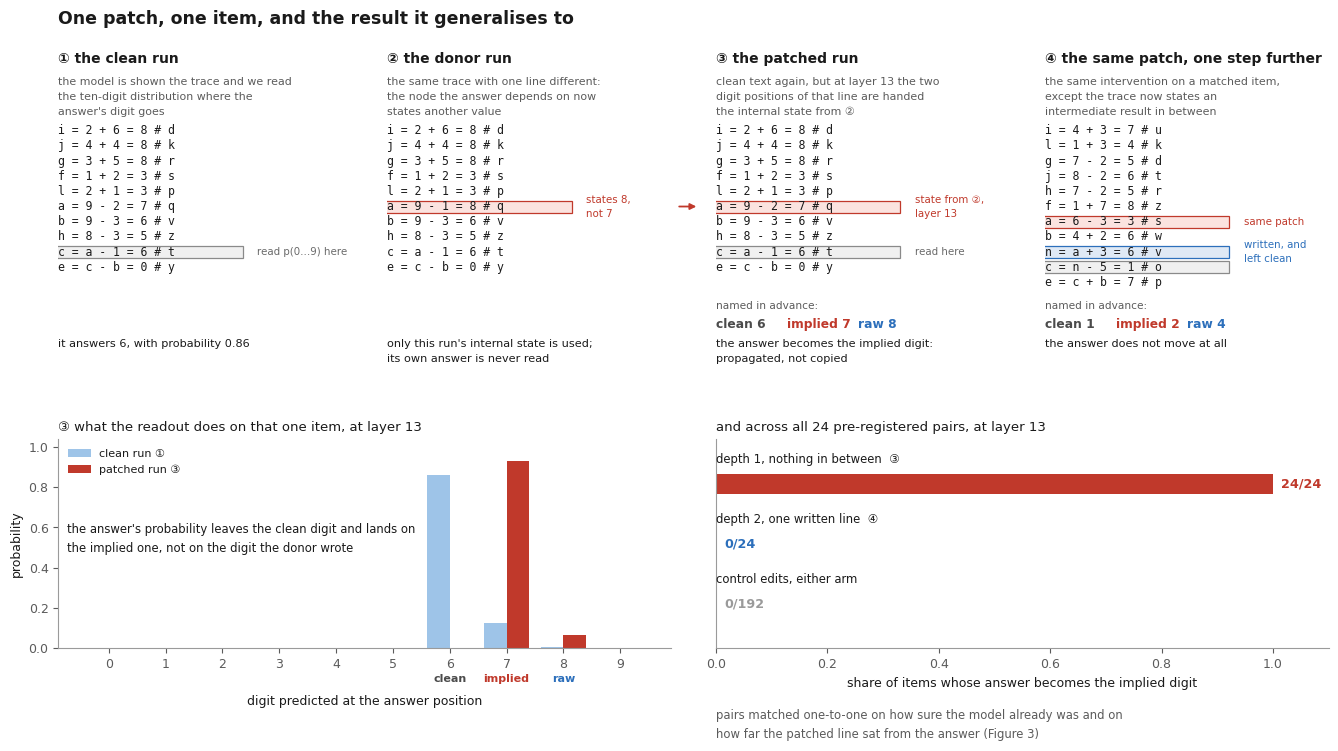

In [2]:
# Figure 1 draws the first item of each pre-registered arm, regenerated from the
# identity that arm stored for it. Generation is deterministic in
# (seed, depth, gap, n_decoys, generator), and the character-level stand-in
# encoder the generator is tested on is enough because only the *text* is drawn
# here -- token positions and distances would need the real tokenizer, so those
# are read from the artifacts instead. Every probability is read, not computed.
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "tests"))
from dag.dag_tasks import generate_items  # noqa: E402
from test_dag_tasks import char_encode  # noqa: E402

PANEL = {}
for depth in (1, 2):
    report = arm(f"e2_stage_b/depth{depth}.json")
    assert report["condition"] == "both"  # the donor line stays arithmetically consistent
    rows = [r for r in report["rows"] if r["kind"] == "ancestor" and r["layer"] == LAYER]
    # Rows carry no item index. They are written item by item -- dag_evidence
    # slices them that way -- and the clean answer sequence is what says so.
    assert [r["clean_value"] for r in rows] == [it["target_value"] for it in report["items"]]
    chosen, row, record = report["selected"][0], rows[0], report["items"][0]
    batch = generate_items(
        char_encode, n_items=chosen["index"] + 1, n_decoys=report["n_decoys"],
        seed=chosen["seed"], condition=report["condition"], depth=chosen["depth"],
        gap=chosen["gap"], generator=report["generator"], omit="none",
    )
    item = batch[chosen["index"]]
    edit = next(e for e in item.edits if e.kind == "ancestor")
    # A regenerated item counts only where it reproduces the archived
    # measurement: the two digits the arm recorded for this item.
    assert item.target_value == row["clean_value"] == record["target_value"]
    assert edit.implied_target_value == row["implied_value"]

    node = item.nodes[edit.node]
    # The donor line, rebuilt: the operand that makes its stated result the raw
    # digit. A donor trace differs from the clean one at the two patched digit
    # positions and nowhere else, so the donor text is the clean text with this
    # one line swapped in.
    operand = (row["raw_value"] - int(node.lhs) if node.op == "+"
               else int(node.lhs) - row["raw_value"])
    lines = item.text.rstrip("\n").split("\n")
    at = next(i for i, line in enumerate(lines) if line.startswith(node.name + " "))
    donor_line = (f"{node.name} = {node.lhs} {node.op} {operand} = {row['raw_value']}"
                  + lines[at][lines[at].index(" #"):])
    assert 0 <= operand <= 9 and len(donor_line) == len(lines[at])
    child = dict(item.edges)
    carried, walk = [], edit.node
    while walk != item.target:
        walk = child[walk]
        carried.append(walk)
    PANEL[depth] = {
        "lines": lines, "donor": [donor_line if i == at else l for i, l in enumerate(lines)],
        "patched": node.name, "answer": item.target, "carried": carried[:-1],
        "row": row, "record": record, "stated": node.value,
    }

BOX = {"patched": ("#fbe3df", COLOR["ancestor"]),
       "carried": ("#dfe9f5", "#2c6fbb"),
       "answer": ("#f0f0f0", "#8a8a8a")}


def card(ax, header, note, panel, lines, boxes, marks=(), named=None, footer=None):
    """One trace, drawn as the model sees it, with the edited lines called out."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0, 1.10, header, fontsize=10, fontweight="600", color=INK, va="top")
    ax.text(0, 1.005, note, fontsize=7.9, color=MUTED, va="top", linespacing=1.6)
    top, step = 0.80, 0.058
    at = {}
    for i, line in enumerate(lines):
        y = top - i * step
        name = line.split(" ", 1)[0]
        at[name] = y
        if name in boxes:
            face, edge = BOX[boxes[name]]
            ax.add_patch(Rectangle((-0.03, y - 0.023), 0.68, 0.046, facecolor=face,
                                   edgecolor=edge, lw=0.9, zorder=0))
        ax.text(0, y, line, family="monospace", fontsize=8.3, va="center", color=INK)
    for name, text, color in marks:
        ax.text(0.70, at[name], text, fontsize=7.4, color=color, va="center",
                linespacing=1.5)
    # The three named digits and the one-line reading sit at a fixed height, so
    # the four cards line up even though their traces differ by a line.
    if named:
        ax.text(0, 0.15, "named in advance:", fontsize=7.6, color=MUTED, va="top")
        for i, (label, value, color) in enumerate(named):
            ax.text(i * 0.25, 0.085, f"{label} {value}", fontsize=8.8,
                    color=color, fontweight="600", va="top")
    if footer:
        ax.text(0, 0.005, footer, fontsize=8.1, color=INK, va="top", linespacing=1.6)
    return at


fig = plt.figure(figsize=(13.4, 7.6))
gs = fig.add_gridspec(2, 4, height_ratios=[1.25, 1], hspace=0.42, wspace=0.16,
                      left=0.042, right=0.99, top=0.885, bottom=0.135)
fig.suptitle("One patch, one item, and the result it generalises to",
             x=0.042, y=0.975, ha="left", fontsize=12.5, fontweight="600")

one, two = PANEL[1], PANEL[2]
clean_digit = one["row"]["clean_value"]
implied_digit = one["row"]["implied_value"]
raw_digit = one["row"]["raw_value"]
NAMED = [("clean", clean_digit, "#4b4b4b"), ("implied", implied_digit, COLOR["ancestor"]),
         ("raw", raw_digit, "#2c6fbb")]

CARDS = [fig.add_subplot(gs[0, i]) for i in range(4)]

card(CARDS[0], "① the clean run",
     "the model is shown the trace and we read\nthe ten-digit distribution where the\nanswer's digit goes",
     one, one["lines"], {one["answer"]: "answer"},
     marks=[(one["answer"], "read p(0…9) here", "#6a6a6a")],
     footer=f"it answers {clean_digit}, with probability "
            f"{one['record']['clean_probs'][clean_digit]:.2f}")

donor_at = card(CARDS[1], "② the donor run",
     "the same trace with one line different:\nthe node the answer depends on now\nstates another value",
     one, one["donor"], {one["patched"]: "patched"},
     marks=[(one["patched"], f"states {raw_digit},\nnot {one['stated']}", COLOR["ancestor"])],
     footer="only this run's internal state is used;\nits own answer is never read")

card(CARDS[2], "③ the patched run",
     f"clean text again, but at layer {LAYER} the two\ndigit positions of that line are handed\nthe internal state from ②",
     one, one["lines"], {one["patched"]: "patched", one["answer"]: "answer"},
     marks=[(one["patched"], f"state from ②,\nlayer {LAYER}", COLOR["ancestor"]),
            (one["answer"], "read here", "#6a6a6a")],
     named=NAMED,
     footer="the answer becomes the implied digit:\npropagated, not copied")

card(CARDS[3], "④ the same patch, one step further",
     "the same intervention on a matched item,\nexcept the trace now states an\nintermediate result in between",
     two, two["lines"],
     {two["patched"]: "patched", two["answer"]: "answer",
      **{name: "carried" for name in two["carried"]}},
     marks=[(two["patched"], "same patch", COLOR["ancestor"]),
            (two["carried"][0], "written, and\nleft clean", "#2c6fbb")],
     named=[("clean", two["row"]["clean_value"], "#4b4b4b"),
            ("implied", two["row"]["implied_value"], COLOR["ancestor"]),
            ("raw", two["row"]["raw_value"], "#2c6fbb")],
     footer="the answer does not move at all")

# the one thing the four cards cannot say in words: what moves between them
CARDS[2].annotate("", xy=(-0.06, donor_at[one["patched"]]), xycoords=CARDS[2].transAxes,
                  xytext=(1.02, donor_at[one["patched"]]), textcoords=CARDS[1].transAxes,
                  arrowprops=dict(arrowstyle="-|>", color=COLOR["ancestor"], lw=1.3))

ax = fig.add_subplot(gs[1, 0:2])
digits = list(range(10))
ax.bar([d - 0.2 for d in digits], one["record"]["clean_probs"], width=0.4,
       color=COLOR["clean"], label="clean run ①")
ax.bar([d + 0.2 for d in digits], one["row"]["probs_patched"], width=0.4,
       color=COLOR["patched"], label="patched run ③")
ax.set_xticks(digits)
ax.set_ylim(0, 1.04)
ax.set_xlabel("digit predicted at the answer position", labelpad=17)
ax.set_ylabel("probability")
ax.set_title(f"③ what the readout does on that one item, at layer {LAYER}", loc="left")
ax.legend(fontsize=8, loc="upper left")
for label, value, color in NAMED:
    ax.annotate(label, xy=(value, 0), xytext=(0, -24), textcoords="offset points",
                ha="center", fontsize=8, fontweight="600", color=color,
                annotation_clip=False)
ax.text(0.015, 0.60, "the answer's probability leaves the clean digit and lands on\n"
                     "the implied one, not on the digit the donor wrote",
        transform=ax.transAxes, fontsize=8.4, va="top", linespacing=1.6)

ax = fig.add_subplot(gs[1, 2:4])
spec = {d: STAGE_B["control_specificity"][d]["per_layer"][str(LAYER)] for d in ("1", "2")}
assert {s["control_moved"] for s in spec.values()} == {0}
BARS = [("depth 1, nothing in between  ③", PRIMARY["hits"]["1"], PRIMARY["n"]["1"], COLOR[1]),
        ("depth 2, one written line  ④", PRIMARY["hits"]["2"], PRIMARY["n"]["2"], COLOR[2]),
        ("control edits, either arm", 0, spec["1"]["n_control"], "#9a9a9a")]
for y, (label, hits, total, color) in zip((2, 1, 0), BARS):
    ax.barh(y, hits / total, height=0.34, color=color, zorder=2)
    ax.text(0, y + 0.30, label, fontsize=8.4, va="bottom")
    ax.text(hits / total + 0.015, y, f"{hits}/{total}", fontsize=9.2, va="center",
            fontweight="600", color=color)
ax.set_ylim(-0.75, 2.75)
ax.set_yticks([])
ax.set_xlim(0, 1.1)
ax.set_xlabel("share of items whose answer becomes the implied digit")
ax.set_title(f"and across all {PRIMARY['n_pairs']} pre-registered pairs, at layer {LAYER}",
             loc="left")
ax.text(0.0, -0.29, "pairs matched one-to-one on how sure the model already was and on\n"
                    "how far the patched line sat from the answer (Figure 3)",
        transform=ax.transAxes, fontsize=8.4, va="top", linespacing=1.6, color=MUTED)
plt.show()

**Figure 1. Intervention and semantic outcomes.** The first three panels show
the clean run, donor run, and native-position transplant. The lower-left panel
shows one readout moving from the clean digit to the recipient-implied digit,
not to the raw donor digit. The lower-right panel gives the pre-registered
matched result: 24/24 one-update items and 0/24 two-update items land on the
implied digit, while matched control edits move 0/192 times. The example explains
the measurement; the aggregate result does not depend on this example.

## 2. Headline result: semantic cliff, distributional decay

E3 scales the ladder to 48 generated items across three seeds and patches the
written intermediates as well as their ancestors. The registered outcome is the
implied digit uniquely on top at layer 13, conditional on a uniquely correct
clean readout.

In [3]:
SITES = pd.DataFrame([
    {
        "site": row["label"],
        "operations remaining": row["steps"],
        "tokens to answer": f"{row['distance_min']}–{row['distance_max']}",
        "n": row["n"],
        "→ implied": f"{row['implied_top_unique']}/{row['n']}",
        "→ raw": f"{row['raw_top_unique']}/{row['n']}",
        "→ clean": f"{row['clean_top_unique']}/{row['n']}",
        "median TV": row["median_tv"],
        "per-seed implied": " · ".join(
            f"{seed['implied_top_unique']}/{seed['n']}" for seed in row["per_seed"]
        ),
    }
    for row in E3["by_site"]
])
table(
    SITES,
    f"Table 1 · semantic outcomes at every E3 patch site, layer {E3['layer']}",
    highlight=[row["steps"] == 1 for row in E3["by_site"]],
    **{"median TV": "{:.4f}"},
    note=("Tinted rows have one written operation remaining. They land on the "
          "recipient-implied digit in 555/603 eligible cases; all sites with two "
          "or more operations remaining land there 0/432 times and preserve the "
          "clean answer 432/432 times. The observations are clustered within "
          "items, placements, arms, and seeds, so the table reports counts and "
          "per-seed rates rather than treating 1,035 sites as independent."),
)

site,operations remaining,tokens to answer,n,→ implied,→ raw,→ clean,median TV,per-seed implied
depth 1 gap 0 ancestor,1,11–24,117,104/117,11/117,0/117,0.9867,35/39 · 33/37 · 36/41
depth 1 gap 1 ancestor,1,24–37,104,87/104,17/104,0/104,0.9833,32/39 · 23/29 · 32/36
depth 1 gap 2 ancestor,1,37–50,94,76/94,18/94,0/94,0.9818,27/32 · 22/28 · 27/34
depth 2 gap 0 chain n,1,11–11,144,144/144,0/144,0/144,0.9961,48/48 · 48/48 · 48/48
depth 2 gap 0 ancestor,2,23–36,144,0/144,0/144,144/144,0.0353,0/48 · 0/48 · 0/48
depth 3 gap 0 chain n,1,11–11,144,144/144,0/144,0/144,0.9992,48/48 · 48/48 · 48/48
depth 3 gap 0 chain m,2,23–23,144,0/144,0/144,144/144,0.0902,0/48 · 0/48 · 0/48
depth 3 gap 0 ancestor,3,35–48,144,0/144,0/144,144/144,0.0030,0/48 · 0/48 · 0/48


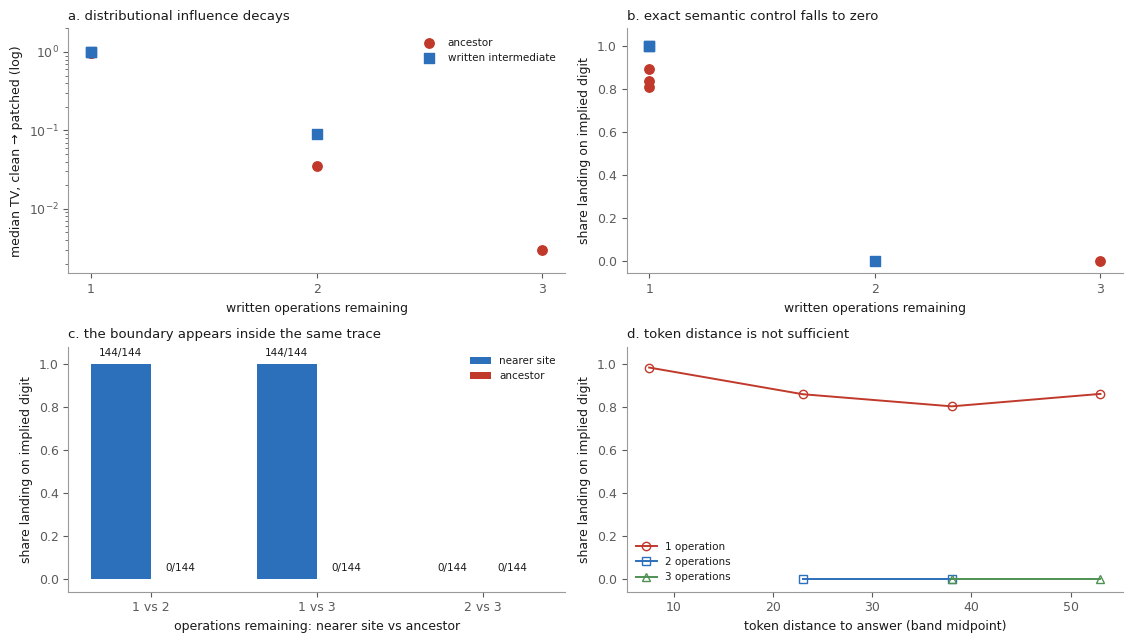

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11.4, 6.5))
MARK = {"ancestor": ("o", COLOR["ancestor"], "ancestor"),
        "chain": ("s", "#2c6fbb", "written intermediate")}

ax = axes[0, 0]
for kind, (marker, colour, label) in MARK.items():
    rows = [r for r in E3["by_site"] if r["kind"] == kind]
    ax.scatter([r["steps"] for r in rows], [r["median_tv"] for r in rows],
               marker=marker, s=46, color=colour, label=label, zorder=3)
ax.set_yscale("log")
ax.set_ylim(1.5e-3, 2.0)
ax.set_xticks([1, 2, 3])
ax.set_xlabel("written operations remaining")
ax.set_ylabel("median TV, clean → patched (log)")
ax.set_title("a. distributional influence decays", loc="left")
ax.legend(fontsize=7.5)

ax = axes[0, 1]
for kind, (marker, colour, label) in MARK.items():
    rows = [r for r in E3["by_site"] if r["kind"] == kind]
    ax.scatter([r["steps"] for r in rows],
               [r["implied_top_unique"] / r["n"] for r in rows],
               marker=marker, s=46, color=colour, label=label, zorder=3)
ax.set_ylim(-0.06, 1.08)
ax.set_xticks([1, 2, 3])
ax.set_xlabel("written operations remaining")
ax.set_ylabel("share landing on implied digit")
ax.set_title("b. exact semantic control falls to zero", loc="left")

ax = axes[1, 0]
labels, chain_share, ancestor_share = [], [], []
for row in E3["within_item"]:
    labels.append(f"{row['chain_steps']} vs {row['ancestor_steps']}")
    chain_share.append((row["chain_only"] + row["both"]) / row["n"])
    ancestor_share.append((row["ancestor_only"] + row["both"]) / row["n"])
x = range(len(labels))
ax.bar([i - 0.18 for i in x], chain_share, width=0.36, color="#2c6fbb",
       label="nearer site")
ax.bar([i + 0.18 for i in x], ancestor_share, width=0.36,
       color=COLOR["ancestor"], label="ancestor")
for i, (near, ancestor, row) in enumerate(zip(chain_share, ancestor_share,
                                               E3["within_item"])):
    ax.text(i - 0.18, near + 0.035, f"{round(near * row['n'])}/{row['n']}",
            ha="center", fontsize=7.5)
    ax.text(i + 0.18, ancestor + 0.035,
            f"{round(ancestor * row['n'])}/{row['n']}", ha="center", fontsize=7.5)
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylim(-0.06, 1.08)
ax.set_xlabel("operations remaining: nearer site vs ancestor")
ax.set_ylabel("share landing on implied digit")
ax.set_title("c. the boundary appears inside the same trace", loc="left")
ax.legend(fontsize=7.5)

ax = axes[1, 1]
for steps, colour, marker in ((1, COLOR[1], "o"), (2, COLOR[2], "s"),
                              (3, COLOR[3], "^")):
    rows = [r for r in E3["by_distance_band"] if r["steps"] == steps]
    if rows:
        ax.plot([sum(r["band"]) / 2 for r in rows],
                [r["implied_top_unique"] / r["n"] for r in rows],
                marker=marker, ms=6, mfc="none", color=colour, lw=1.4,
                label=f"{steps} operation" + "s" * (steps > 1))
ax.set_ylim(-0.06, 1.08)
ax.set_xlabel("token distance to answer (band midpoint)")
ax.set_ylabel("share landing on implied digit")
ax.set_title("d. token distance is not sufficient", loc="left")
ax.legend(fontsize=7.5)

fig.tight_layout()
plt.show()

**Figure 2. The main empirical result.** Panel a shows a graded change in the
digit distribution: median TV falls from about 0.99 at one operation to
0.035–0.090 at two and 0.003 at three. Panel b shows a different pattern in the
semantic outcome: one-update sites often install the implied digit, while every
measured multi-update site remains at zero. Panel c makes the comparison within
the same trace. A last intermediate succeeds in 144/144 items where its ancestor
succeeds in 0/144; a two-update written intermediate and its three-update
ancestor both remain at zero. Panel d shows that one- and multi-update sites
remain separated inside overlapping token-distance bands. These controls locate
an immediate-read boundary in this format. They do not make written-step count
the only changing property.

## 3. Pre-registered confirmation removes two measured confounds

The discovery items coupled the intervention with clean difficulty and token
distance. Stage A therefore screened clean traces without patching. A rule
registered before the selected items existed matched 24 depth-1 and depth-2
pairs on clean `p(target)` and ancestor distance. Stage B patched only those
pairs at the inherited layer 13.

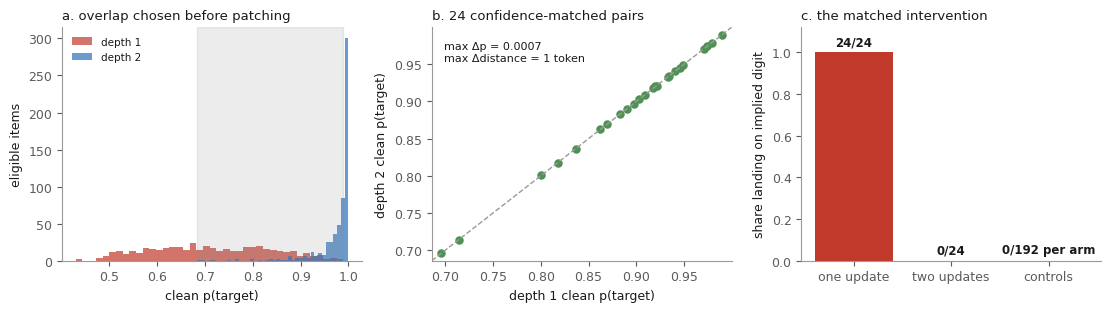

In [5]:
screened = pd.DataFrame(SELECTION["screened"])
pairs = SELECTION["selection"]["pairs"]
low, high = SELECTION["selection"]["window"]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2))
ax = axes[0]
for depth, frame in screened.groupby("depth"):
    eligible = frame[frame["clean_correct_unique"]]
    ax.hist(eligible["clean_target_share"], bins=40, alpha=0.7,
            label=f"depth {depth}", color=COLOR[depth])
ax.axvspan(low, high, color="#8a8a8a", alpha=0.16)
ax.set_xlabel("clean p(target)")
ax.set_ylabel("eligible items")
ax.set_title("a. overlap chosen before patching", loc="left")
ax.legend(fontsize=7.5)

ax = axes[1]
p1 = [pair[0]["clean_target_share"] for pair in pairs]
p2 = [pair[1]["clean_target_share"] for pair in pairs]
ax.scatter(p1, p2, s=26, color="#4f9153")
limits = [min(p1 + p2) - 0.01, max(p1 + p2) + 0.01]
ax.plot(limits, limits, color="#9a9a9a", lw=1, ls="--")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("depth 1 clean p(target)")
ax.set_ylabel("depth 2 clean p(target)")
ax.set_title("b. 24 confidence-matched pairs", loc="left")
worst_p = max(abs(a["clean_target_share"] - b["clean_target_share"])
              for a, b in pairs)
worst_d = max(abs(a["ancestor_distance"] - b["ancestor_distance"])
              for a, b in pairs)
ax.text(0.04, 0.94, f"max Δp = {worst_p:.4f}\nmax Δdistance = {worst_d} token",
        transform=ax.transAxes, va="top", fontsize=8)

ax = axes[2]
spec = STAGE_B["control_specificity"]
control = spec["1"]["per_layer"][str(LAYER)]
assert all(spec[d]["per_layer"][str(LAYER)][key] == control[key]
           for d in ("1", "2") for key in ("control_moved", "n_control"))
control_moved, control_n = control["control_moved"], control["n_control"]
values = [PRIMARY["hits"]["1"] / PRIMARY["n"]["1"],
          PRIMARY["hits"]["2"] / PRIMARY["n"]["2"],
          control_moved / control_n]
labels = ["one update", "two updates", "controls"]
bars = ax.bar(labels, values, color=[COLOR[1], COLOR[2], "#9a9a9a"])
for bar, hit, total in zip(bars,
                           [PRIMARY["hits"]["1"], PRIMARY["hits"]["2"], control_moved],
                           [PRIMARY["n"]["1"], PRIMARY["n"]["2"], control_n]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.035,
            f"{hit}/{total}" + (" per arm" if total == control_n else ""),
            ha="center", fontsize=8.5, fontweight="600")
ax.set_ylim(0, 1.12)
ax.set_ylabel("share landing on implied digit")
ax.set_title("c. the matched intervention", loc="left")

fig.tight_layout()
plt.show()

**Figure 3. Confirmatory matched test.** The matching procedure saw clean
forward passes but no patch outcomes. The 24 selected pairs differ by at most
0.0007 in clean `p(target)` and one token in ancestor distance. At layer 13, all
24 one-update interventions and no two-update interventions land on the implied
digit; matched non-ancestor, null, and surface controls move 0/192 times. The
one-sided exact paired test is `p = 2⁻²⁴ = 5.96e-8`. This confirms the contrast
in the high-confidence overlap region. It does not reselect the layer or estimate
a general population rate.

## 4. The transplant carries the stated result, with some literal copying

The one-update ancestor result is a mixture. Across E3, the implied digit is top
in 267/315 cases, the raw donor digit in 46/315, and the clean digit in 0/315.
Recipient-side transformation dominates, but the ancestor edit is not pure
symbolic propagation. The written last-intermediate edit is cleaner: implied
288/288 and raw 0/288.

A small donor-split pilot asks which part of the donor line supplies the effect.

In [6]:
SPLIT = {"feasibility.json": "both: operand and stated result",
         "result_only.json": "result only: the stated digit changes",
         "operand_only.json": "operand only: the stated digit stays clean"}
rows = []
for name, label in SPLIT.items():
    payload = arm(name)
    frame = pd.DataFrame(payload["rows"])
    at13 = frame[frame["layer"] == LAYER]
    ancestor = at13[at13["kind"] == "ancestor"]
    rows.append({
        "donor edit": label,
        "median TV, ancestor": ancestor["tv"].median(),
        "median TV, non-ancestor": at13[at13["kind"] == "non_ancestor"]["tv"].median(),
        "median Δ log-odds toward implied": ancestor["delta_toward"].median(),
        "verdict": payload["verdict"],
    })
table(
    pd.DataFrame(rows), f"Table 2 · which half of the donor line does the work, layer {LAYER}",
    highlight=[False, True, False],
    note=("The archived pilot: five items, one seed, the <code>v1_unpaired</code> "
          "family, bfloat16, rescored under the current verdict policy. Changing "
          "the written result reproduces the whole consistent effect; changing an "
          "operand and leaving the written result alone does not separate from the "
          "matched non-ancestor. So the propagated quantity in the one-update result is the "
          "donor's <b>stated</b> value. This split has not been rerun on "
          "<code>v3_distinct</code>, and five items is a pilot; it is a supporting  "
          "pilot, not a headline result."),
    **{"median TV, ancestor": "{:.3f}", "median TV, non-ancestor": "{:.3f}",
       "median Δ log-odds toward implied": "{:+.2f}"},
)

donor edit,"median TV, ancestor","median TV, non-ancestor",median Δ log-odds toward implied,verdict
both: operand and stated result,0.844,0.017,+7.13,positive
result only: the stated digit changes,0.837,0.087,+6.83,positive
operand only: the stated digit stays clean,0.078,0.061,+1.10,scientific negative


## 5. Controls define the claim boundary

The failed or limited controls belong beside the positive result. They prevent a
semantic boundary from becoming a claim that the model implements the generated
DAG or that written text overwrites latent state.

In [7]:
spec = STAGE_B["control_specificity"]
control = spec["1"]["per_layer"][str(LAYER)]
assert all(spec[d]["per_layer"][str(LAYER)][key] == control[key]
           for d in ("1", "2") for key in ("control_moved", "n_control"))
control_moved, control_n = control["control_moved"], control["n_control"]

cross = [arm(f"v3_distinct/cross_seed{seed}.json")["gates"]["cross_item_donor"]
         for seed in range(4)]

omit = []
for depth in (2, 3):
    payload = arm(f"written_vs_omitted/depth{depth}_chain.json")
    clean = payload["gates"]["clean_answer"]
    shares = [item["clean_probs"][item["target_value"]] for item in payload["items"]]
    omit.append(f"d{depth}: {clean['n_unique_correct']}/{clean['n_items']}, "
                f"median p={pd.Series(shares).median():.3f}")

gap = E3["by_distance_paired"]
near, far = gap["per_gap"][0], gap["per_gap"][-1]
rows = [
    {
        "check": "matched quiet controls",
        "observation": f"{control_moved}/{control_n} moved per arm at layer {LAYER}",
        "reading": "the matched intervention is not a generic token-position effect",
    },
    {
        "check": "foreign-item donor",
        "observation": f"specificity passed {sum(g['passes'] for g in cross)}/4 seeds",
        "reading": "portable-state selectivity remains unresolved",
    },
    {
        "check": "omit written path value",
        "observation": "; ".join(omit),
        "reading": "clean competence collapses, so overwrite is not identified",
    },
    {
        "check": "same items at three gaps",
        "observation": (f"implied {near['implied_top_unique']}/{near['n_complete_case']} → "
                        f"{far['implied_top_unique']}/{far['n_complete_case']}; "
                        f"raw {near['raw_top_unique']} → {far['raw_top_unique']}"),
        "reading": "placement and clean confidence move together",
    },
]
table(pd.DataFrame(rows), "Table 3 · controls that set the paper's claim boundary",
      note=("The first row supports the intervention. The other rows limit its "
            "interpretation. The omission pilot has five items per arm; the gap "
            "analysis is exploratory and clustered by item."))

check,observation,reading
matched quiet controls,0/192 moved per arm at layer 13,the matched intervention is not a generic token-position effect
foreign-item donor,specificity passed 1/4 seeds,portable-state selectivity remains unresolved
omit written path value,"d2: 2/5, median p=0.240; d3: 1/5, median p=0.050","clean competence collapses, so overwrite is not identified"
same items at three gaps,implied 76/81 → 67/81; raw 3 → 14,placement and clean confidence move together


## 6. Relation to prior work

Interchange interventions already test whether neural states play the causal
role of variables in a high-level program ([Geiger et al.,
2021](https://arxiv.org/abs/2106.02997)). Prior work also studies causal
arithmetic chain-of-thought ([Tan,
2023](https://aclanthology.org/2023.blackboxnlp-1.12/)), task-grounded
mechanistic intervention ([Brinkmann et al.,
2024](https://aclanthology.org/2024.findings-acl.242/)), and hidden-state
transplantation ([Patchscopes](https://openreview.net/forum?id=5uwBzcn885)).

The closest precedent is [Shih, Winnicki, and Darve
2026](https://arxiv.org/abs/2606.29522). They compare an unmodified pretrained
base with matched final-answer-only and running-state LoRA models. Only the
running-state targets include intermediate states, and that model develops a
causal register that persists across later updates. Their conflicting-
continuation control already separates computation from copying. Our
clean/implied/raw assay adds a per-item arithmetic outcome rather than a new kind
of control.

[Kudo et al. 2026](https://aclanthology.org/2026.findings-eacl.59/) show that
models compute sub-answers during CoT generation. They ask when a value first
becomes available; we ask what controls the answer after the value is written.
The results address different stages of the trace.

[Garcia 2026](https://arxiv.org/abs/2605.10799) shows that corruption sensitivity
can track explicit answer placement. Our token-distance bands and same-trace
comparison rule out placement alone. They do not separate written-step count
from patch-site role or local context.

The contribution is therefore the arithmetic clean/implied/raw assay and the
controlled empirical boundary it reveals. It is not the first activation
intervention on chain-of-thought, the first graph-grounded patching study, or the
first computation-versus-copy control. The persistence difference from Shih is
consistent with a supervision hypothesis, but the papers differ in model, task,
intervention, and outcome. The comparison does not identify the cause.

## 7. Paper conclusion and open scope

The transplant usually has the expected causal role in the recipient's next
arithmetic update. Through another explicitly written update, it still perturbs
the answer distribution but never installs the predicted counterfactual answer
in the measured sites. Exact semantic control and distributional influence are
therefore different estimands.

The result does not show that the model represents the generated DAG, that
transformers cannot maintain latent state, or that a written value overwrites a
latent one. The main limits are one checkpoint, one operation family, one
notation, teacher-forced traces, a layer inherited from discovery, a failed
cross-item specificity control, and a depth manipulation that also changes
operation, binding, context, and site role.

For the workshop paper, the experiments are complete. The next main-track fork
is a clean-only screen for a model and format that remain competent when a path
intermediate is unwritten. If none clears that gate, the sharper experiment is a
same-task comparison of final-answer-only and running-state supervision.

### Provenance

- Full experimental narrative: [notebook 15](15_dag_paper_story.ipynb)
- Paper strategy: [`PAPER_STRATEGY_DAG.md`](../PAPER_STRATEGY_DAG.md)
- Claim and literature boundary:
  [`docs/research/2026-08-16-dag-literature-and-claim-boundary.md`](../docs/research/2026-08-16-dag-literature-and-claim-boundary.md)
- Main analysis: [`results/dag_patching/e3_ladder/ANALYSIS.json`](../results/dag_patching/e3_ladder/ANALYSIS.json)
- Pre-registered matched analysis:
  [`results/dag_patching/e2_stage_b/ANALYSIS.json`](../results/dag_patching/e2_stage_b/ANALYSIS.json)